In [1]:
""" Bode_comp_example.ipynb """

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
from math import pi, exp, cos, sin, log, sqrt
from control import margin
from control import tf

<>:45: SyntaxWarning: invalid escape sequence '\o'
<>:45: SyntaxWarning: invalid escape sequence '\o'
C:\Users\gjsta\AppData\Local\Temp\ipykernel_24620\11610120.py:45: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')
C:\Users\gjsta\anaconda3\Lib\site-packages\scipy\signal\_ltisys.py:600: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


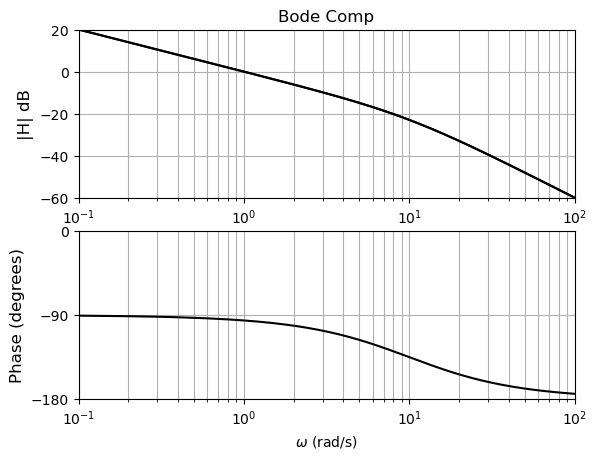

In [2]:
K = 1
n1 = [ 0, 0,K* 10]
d1 = [1, 10, 0 ]

# First Gc
n2 = [1,1.9]
d2 = [1,4.7]
K = 4.7/1.9
n12 = K*np.convolve(n1,n2)
d12 = np.convolve(d1,d2)

# Second Gc
n3 = [1,4]
d3 = [1,40]
n123 = np.convolve(n12,n3)
d123 = np.convolve(d12,d3)
num = n1
den = d1

w = np.linspace(0.1,100,num=1000)
system = sig.lti(num,den)
w, Hmag, Hphase = sig.bode(system,w)
gm, pm, wg, wp = margin(Hmag,Hphase,w)
# wp freq for phase margin at gain crossover (gain = 1)
# pm phase maring

plt.subplot(211)
plt.semilogx(w,Hmag,'k')
plt.semilogx(w,Hmag,'k')
plt.axis([ .1, 1e2, -60, 20])
#plt.xticks([1,10,30,100,1000])
plt.ylabel('|H| dB',size = 12)
#plt.text(.3,-40,'$\omega$p = {}'.format(round(wp,1)),fontsize=12)
plt.title('Bode Comp')
plt.grid(which='both')

for n in range(100):
    if Hphase[n] > 0:
        Hphase[n] = Hphase[n] - 360

plt.subplot(212)
plt.semilogx(w,Hphase,'k')
plt.axis([ .1, 1e2, -180,0])
plt.yticks([-180,-90,0])
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('Phase (degrees)',size=12)
#plt.text(.3,-150,'pm = {}'.format(round(pm,0)),fontsize=12)
plt.grid(which='both')
plt.show()

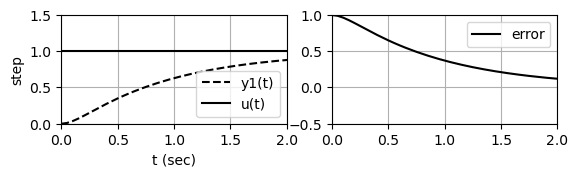

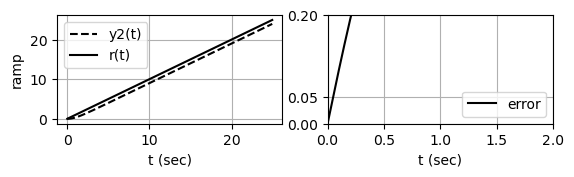

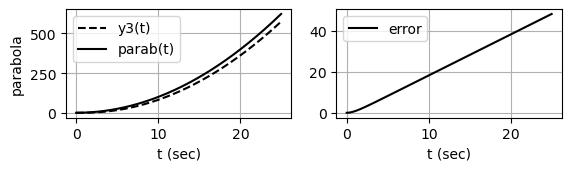

In [3]:
""" Time portion """

dt = 0.05
NN = 500
TT = np.arange(0,NN*dt,dt)
step = np.zeros(NN)
ramp = np.zeros(NN)
parabola = np.zeros(NN)
errS = np.zeros(NN)
errR = np.zeros(NN)
errP = np.zeros(NN)

for i in range(NN):
    step[i] = 1.0
    ramp[i] = (dt*i)
    parabola[i] = (dt*i)**(2)
    
denCL = np.add(num,den)

t1, y1, x1 = sig.lsim((num,denCL),step,TT)
t2, y2, x2 = sig.lsim((num,denCL),ramp,TT)
t3, y3, x3 = sig.lsim((num,denCL),parabola,TT)

for i in range(NN):
    errS[i] = step[i] - y1[i]
    errR[i] = ramp[i] - y2[i]
    errP[i] = parabola[i] - y3[i]

plt.subplot(321)
plt.plot(TT,y1,'k--',label='y1(t)')
plt.plot(TT,step,'k',label='u(t)')
plt.axis([0,2,0,1.5])
plt.ylabel('step')
plt.xlabel('t (sec)')
#plt.yticks([0,.9,1.1,1.5])
plt.legend()
plt.grid()

plt.subplot(322)
plt.plot(TT,errS,'k',label='error')
plt.legend()
plt.axis([0,2,-.5,1])
#plt.yticks([0,0.02,.05,.1])
plt.grid()
plt.savefig('position.png')
plt.show()

plt.subplot(321)
plt.plot(TT,y2,'k--',label='y2(t)')
plt.plot(TT,ramp,'k',label='r(t)')
plt.xlabel('t (sec)')
plt.ylabel('ramp')
plt.legend()
plt.grid()

plt.subplot(322)
plt.plot(TT,errR,'k',label='error')
plt.legend(loc=4)
plt.xlabel('t (sec)')
plt.axis([0,2,0,.2])
plt.yticks([0,.05,.2])
plt.grid()
plt.savefig('velocity.png')
plt.show()

plt.subplot(321)
plt.plot(TT,y3,'k--',label='y3(t)')
plt.plot(TT,parabola,'k',label='parab(t)')
plt.xlabel('t (sec)')
plt.ylabel('parabola')
plt.legend()
plt.grid()

plt.subplot(322)
plt.plot(TT,errP,'k',label='error')
plt.xlabel('t (sec)')
plt.legend()
plt.grid()
#plt.savefig('time_plots.png',dpi=300)
plt.show()